# Lorenz63 metric curves

This notebook is split from `L63_results.ipynb` and only renders metric-vs-N curves and relative-improvement curves. It preserves the original output directory: `save/figures/lorenz63_multi_obs_notebook`.


In [1]:
# Path bootstrap: if running from ./test_notebooks, move to project root
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if cwd.name == 'test_notebooks':
    os.chdir(cwd.parent)
    cwd = Path.cwd().resolve()

print('Current working directory:', cwd)


Current working directory: /home/bhchen/LearnKalmanGain


In [2]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# torch is required to read output_records_*.pt
import torch


In [3]:
# Ensure cwd is project root (where ./save exists)
cwd = Path.cwd().resolve()
if not (cwd / 'save').exists() and (cwd.parent / 'save').exists():
    os.chdir(cwd.parent)

PROJECT_ROOT = Path.cwd().resolve()
SAVE_DIR = PROJECT_ROOT / 'save'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SAVE_DIR exists =', SAVE_DIR.exists())


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
SAVE_DIR exists = True


In [4]:
# =========================
# User config for metric curves
# =========================
DATASET = 'lorenz63'
OBS_FN = 'square'  # default obs_fn for diagnostics printed below
ALL_OBS_FNS = ['identity', 'square', 'arctan']
METRIC_OBS_FN_LIST = ['square', 'arctan', 'identity']
OBS_FN_SIGMA_Y = {
    'identity': 2.0,
    'square': 16.97,
    'arctan': 0.32,
}
SIGMA_Y = OBS_FN_SIGMA_Y[OBS_FN]

AXIS_LABEL_FONTSIZE = 24
TICK_FONTSIZE = 20

VAL_N_LIST = [5, 10, 15, 20, 40, 60, 100]
RESULTS_ROOT = SAVE_DIR / f'{DATASET}_results'
FIG_SAVE_DIR = SAVE_DIR / 'figures' / f'{DATASET}_multi_obs_notebook'
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('RESULTS_ROOT =', RESULTS_ROOT)
print('FIG_SAVE_DIR =', FIG_SAVE_DIR)
print('METRIC_OBS_FN_LIST =', METRIC_OBS_FN_LIST)


RESULTS_ROOT = /home/bhchen/LearnKalmanGain/save/lorenz63_results
FIG_SAVE_DIR = /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook
METRIC_OBS_FN_LIST = ['square', 'arctan', 'identity']


In [5]:
def safe_torch_load(path):
    path = str(path)
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def save_figure_png_pdf(fig, png_path, **savefig_kwargs):
    png_path = Path(png_path)
    pdf_path = png_path.with_suffix('.pdf')
    fig.savefig(png_path, **savefig_kwargs)
    fig.savefig(pdf_path, **savefig_kwargs)
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return png_path, pdf_path


def _score_path(path, preferred_tokens=None):
    preferred_tokens = preferred_tokens or []
    s = 0
    p = str(path)
    for tok in preferred_tokens:
        if tok in p:
            s += 10
    return s


def pick_best_path(paths, preferred_tokens=None):
    paths = list(paths)
    if not paths:
        return None
    scored = sorted(paths, key=lambda p: _score_path(p, preferred_tokens), reverse=True)
    return Path(scored[0])


def get_pf_vis_dir(obs_fn: str) -> Path:
    candidates = []
    if obs_fn == 'identity':
        candidates.extend([
            SAVE_DIR / f'{DATASET}_pf_vis_identity',
            SAVE_DIR / f'{DATASET}_pf_vis',
        ])
    else:
        candidates.append(SAVE_DIR / f'{DATASET}_pf_vis_{obs_fn}')
    candidates.append(SAVE_DIR / f'{DATASET}_pf_vis')

    for cand in candidates:
        if cand.exists():
            return cand
    return candidates[0]


BENCHMARK_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'iEnKS-PertObs': 2,
}
BENCHMARK_METHOD_LABELS = {
    'iEnKS-PertObs': 'IEnKF',
}


def discover_benchmark_dirs(obs_fn: str):
    sigma_y = OBS_FN_SIGMA_Y[obs_fn]
    benchmark_root = SAVE_DIR / f'benchmark_{DATASET}'
    benchmark_glob = str(benchmark_root / f'benchmark_{DATASET}_{sigma_y}_*')
    dirs = [Path(p) for p in glob.glob(benchmark_glob) if Path(p).is_dir()]
    out = []
    prefix = f'benchmark_{DATASET}_{sigma_y}_'
    for d in dirs:
        name = d.name
        method = name.replace(prefix, '') if name.startswith(prefix) else name
        if method not in BENCHMARK_METHOD_ORDER:
            continue
        out.append({
            'label': BENCHMARK_METHOD_LABELS.get(method, method),
            'dir': d,
            'kind': 'classic',
            'method': method,
            'obs_fn': obs_fn,
        })

    out.sort(key=lambda spec: (BENCHMARK_METHOD_ORDER[spec['method']], spec['dir'].name))
    return out


def _has_any_output_records(folder):
    return any(folder.glob('output_records_*.pt'))


TRAINING_MODEL_ORDER = {'ES': 0, 'NL2': 1}
TRAINING_LOSS_ORDER = {'EtE-LRes': 0, 'CorrTerms': 1}


def format_training_label(model: str, loss: str) -> str:
    if loss == 'EtE-LRes':
        return f'EtE + {model}'
    return f'{loss}+{model}'


def parse_training_folder(folder_name: str):
    m = re.search(r'_(?P<model>es|nl2)_joint_(?P<loss>[^_/]+)None_(?P<obs_fn>.+)$', folder_name)
    if not m:
        return None
    return {
        'model': m.group('model').upper(),
        'loss': m.group('loss').replace('None', '').strip('_'),
        'obs_fn': m.group('obs_fn'),
    }


def discover_training_dirs(obs_fn: str, root: Path = RESULTS_ROOT):
    if (not root.exists()) or (not root.is_dir()):
        return []

    specs = []
    for d in sorted(root.iterdir()):
        if (not d.is_dir()) or (not _has_any_output_records(d)):
            continue
        meta = parse_training_folder(d.name)
        if meta is None or meta['obs_fn'] != obs_fn:
            continue
        if meta['model'] not in TRAINING_MODEL_ORDER or meta['loss'] not in TRAINING_LOSS_ORDER:
            continue
        specs.append({
            'label': format_training_label(meta['model'], meta['loss']),
            'dir': d,
            'kind': 'train',
            'model': meta['model'],
            'loss': meta['loss'],
            'obs_fn': obs_fn,
        })

    specs.sort(
        key=lambda spec: (
            TRAINING_MODEL_ORDER[spec['model']],
            TRAINING_LOSS_ORDER[spec['loss']],
            spec['dir'].name,
        )
    )
    return specs


def build_obs_fn_bundle(obs_fn: str):
    return {
        'obs_fn': obs_fn,
        'sigma_y': OBS_FN_SIGMA_Y[obs_fn],
        'pf_dir': get_pf_vis_dir(obs_fn),
        'benchmark_specs': discover_benchmark_dirs(obs_fn),
        'training_specs': discover_training_dirs(obs_fn, RESULTS_ROOT),
        'training_root': RESULTS_ROOT,
    }


def metric_from_record(record_dict, key_candidates):
    candidate_bases = [
        record_dict.get('nn', {}),
        record_dict.get('test_results', {}),
        record_dict,
    ]
    for base in candidate_bases:
        if not isinstance(base, dict):
            continue
        for k in key_candidates:
            if k in base and base[k] is not None:
                try:
                    return float(base[k])
                except Exception:
                    continue
    return np.nan


In [6]:
obs_fn_bundles = {obs_fn: build_obs_fn_bundle(obs_fn) for obs_fn in ALL_OBS_FNS}

default_bundle = obs_fn_bundles[OBS_FN]
PF_VIS_DIR = default_bundle['pf_dir']
benchmark_specs = default_bundle['benchmark_specs']
training_specs = default_bundle['training_specs']
training_root_used = default_bundle['training_root']

print(f'[default={OBS_FN}] PF_VIS_DIR:', PF_VIS_DIR)
print(f'[default={OBS_FN}] Training root used:', training_root_used)
print(f'[default={OBS_FN}] Benchmark dirs found:', len(benchmark_specs))
for s in benchmark_specs:
    print('  -', s['label'], '|', s['dir'])
print(f'[default={OBS_FN}] Training dirs found:', len(training_specs))
for s in training_specs:
    print('  -', s['label'], '|', s['dir'])

for obs_fn in ALL_OBS_FNS:
    bundle = obs_fn_bundles[obs_fn]
    print('==================================================')
    print(f'obs_fn={obs_fn} | sigma_y={bundle["sigma_y"]}')
    print('PF_VIS_DIR:', bundle['pf_dir'])
    print('Benchmark dirs found:', len(bundle['benchmark_specs']))
    for s in bundle['benchmark_specs']:
        print('  -', s['label'], '|', s['dir'])
    print('Training root used:', bundle['training_root'])
    print('Training dirs found:', len(bundle['training_specs']))
    for s in bundle['training_specs']:
        print('  -', s['label'], '|', s['dir'])


[default=square] PF_VIS_DIR: /home/bhchen/LearnKalmanGain/save/lorenz63_pf_vis_square
[default=square] Training root used: /home/bhchen/LearnKalmanGain/save/lorenz63_results
[default=square] Benchmark dirs found: 3
  - ESRF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_16.97_ESRF
  - EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_16.97_EnKF
  - IEnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_16.97_iEnKS-PertObs
[default=square] Training dirs found: 4
  - EtE + ES | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-22_20-23lorenz63_16.97_10_60_8192_es_joint_EtE-LResNone_square
  - CorrTerms+ES | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-22_20-24lorenz63_16.97_10_60_8192_es_joint_CorrTermsNone_square
  - EtE + NL2 | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-22_20-23lorenz63_16.97_10_60_8192_nl2_joint_EtE-LResNone_square
  - CorrTerms+NL2 | /home/bhchen/Le

## Metric definitions

Adjust `METRIC_SPECS`, `METRIC_OBS_FN_LIST`, or `VAL_N_LIST` above/below to change which curves are generated.


In [7]:
METRIC_SPECS = [
    ('PF-SED State', ['mean_pf_sed_state_avg', 'mean_pf_crps_state_avg'], True),
    ('PF-SED PCA', ['mean_pf_sed_pca_avg', 'mean_pf_crps_pca_avg'], True),
    ('PF-SED Total', ['mean_pf_sed', 'mean_pf_crps'], True),
    ('RES1', ['mean_res1_traj', 'mean_res1', 'res1', 'mean_res1_step'], True),
    ('Rank-Hist Var', ['rank_freq_var'], False),
]

METRIC_FIG_WIDTH = 5.4
METRIC_FIG_HEIGHT = 4.4
METRIC_COMBINED_COLS = 2
METRIC_EQUAL_SPACING_WIDTH_THRESHOLD = 7.5

METRIC_LEGEND_WIDTH = 1.9
METRIC_LEGEND_HEIGHT_PER_ITEM = 0.42
METRIC_LEGEND_BASE_HEIGHT = 0.3


def collect_metric_table(method_specs, n_values, metric_key_candidates):
    xs, ys = [], []
    for N in n_values:
        rec_path = method_specs['dir'] / f'output_records_{N}.pt'
        if rec_path.exists():
            record = safe_torch_load(rec_path)
            val = metric_from_record(record, metric_key_candidates)
        else:
            val = np.nan
        xs.append(N)
        ys.append(val)
    return np.array(xs, dtype=float), np.array(ys, dtype=float)


metric_method_specs = {
    obs_fn: obs_fn_bundles[obs_fn]['benchmark_specs'] + obs_fn_bundles[obs_fn]['training_specs']
    for obs_fn in METRIC_OBS_FN_LIST
}

BASELINE_METHOD_LABEL = 'EtE + ES'

for obs_fn in METRIC_OBS_FN_LIST:
    print(f'[metrics] obs_fn={obs_fn} | methods={len(metric_method_specs[obs_fn])}')
    for s in metric_method_specs[obs_fn]:
        print(' -', s['label'])


[metrics] obs_fn=square | methods=7
 - ESRF
 - EnKF
 - IEnKF
 - EtE + ES
 - CorrTerms+ES
 - EtE + NL2
 - CorrTerms+NL2
[metrics] obs_fn=arctan | methods=7
 - ESRF
 - EnKF
 - IEnKF
 - EtE + ES
 - CorrTerms+ES
 - EtE + NL2
 - CorrTerms+NL2
[metrics] obs_fn=identity | methods=7
 - ESRF
 - EnKF
 - IEnKF
 - EtE + ES
 - CorrTerms+ES
 - EtE + NL2
 - CorrTerms+NL2


## Plot metric curves

The cell below saves PNG/PDF copies for each metric and obs function.


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_State.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_State.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_State_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_State_rel_imp.pdf


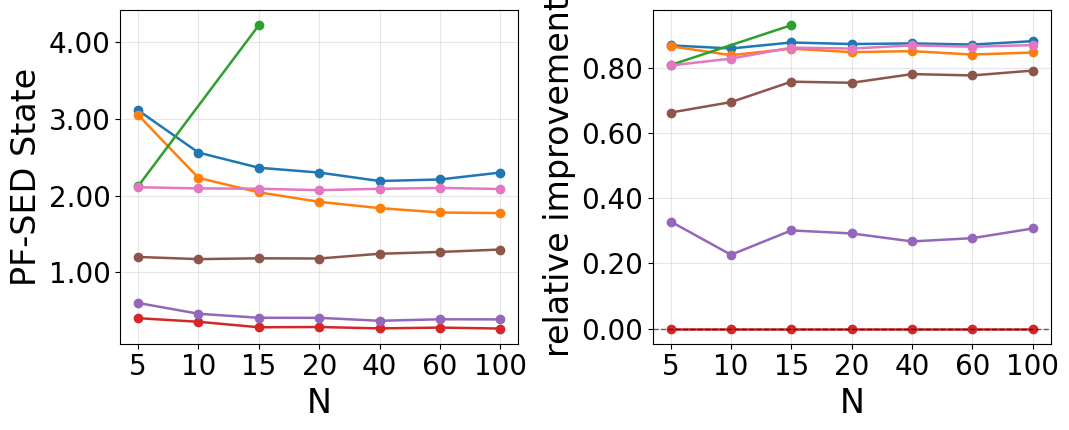

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_PCA.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_PCA.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_PCA_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_PCA_rel_imp.pdf


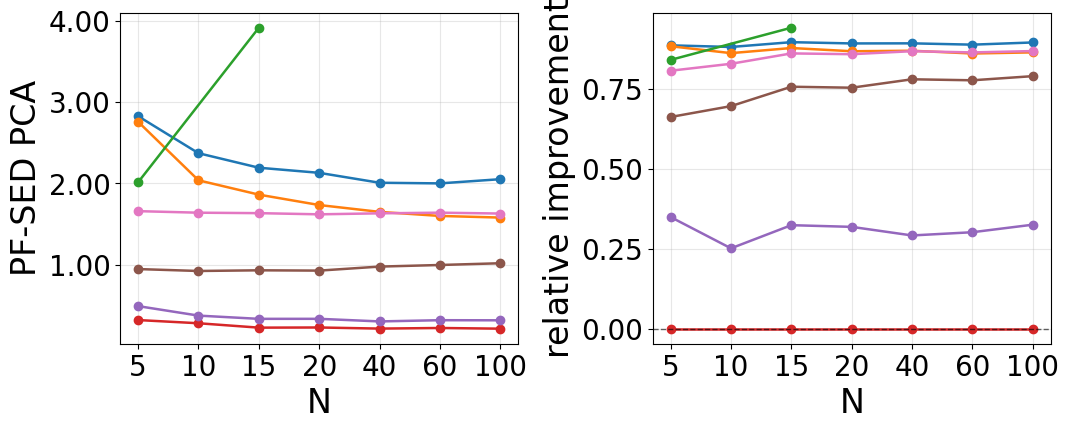

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_Total.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_Total.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_Total_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_PF-SED_Total_rel_imp.pdf


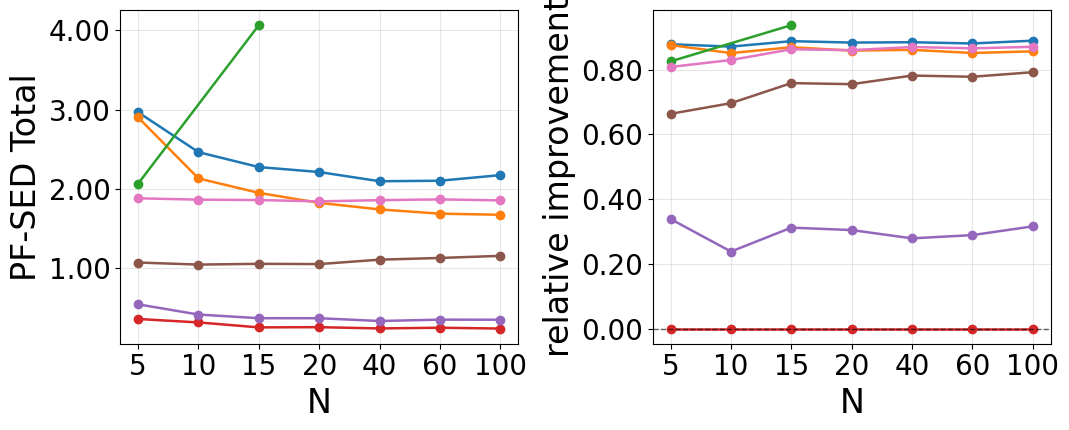

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_RES1.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_RES1.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_RES1_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_RES1_rel_imp.pdf


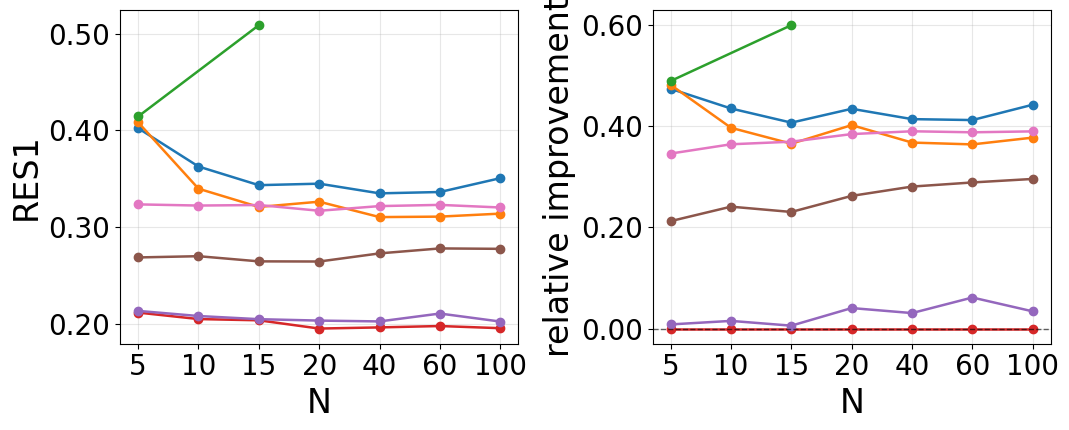

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_Rank-Hist_Var.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_square_vs_N_Rank-Hist_Var.pdf


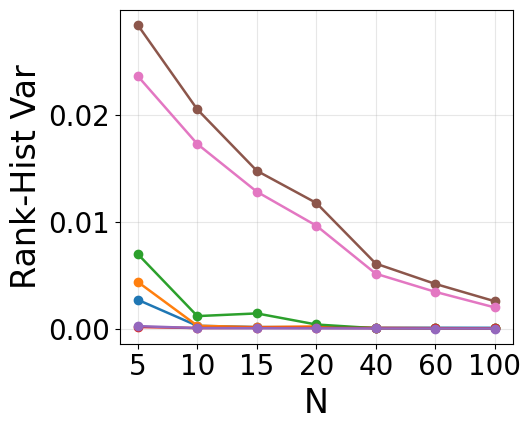

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_State.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_State.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_State_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_State_rel_imp.pdf


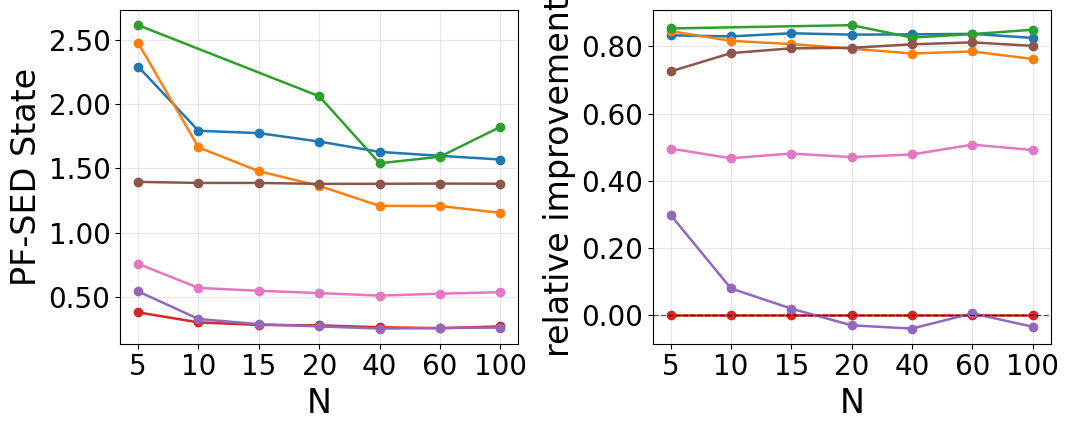

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_PCA.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_PCA.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_PCA_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_PCA_rel_imp.pdf


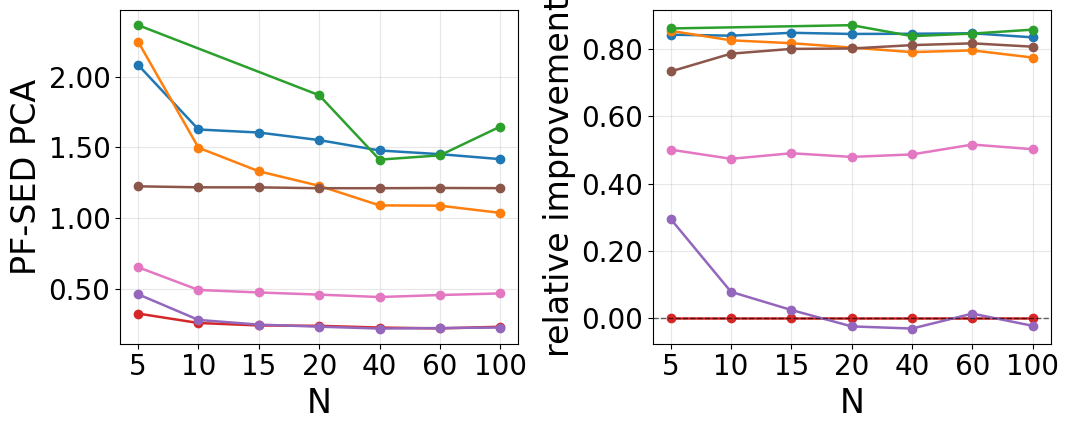

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_Total.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_Total.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_Total_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_PF-SED_Total_rel_imp.pdf


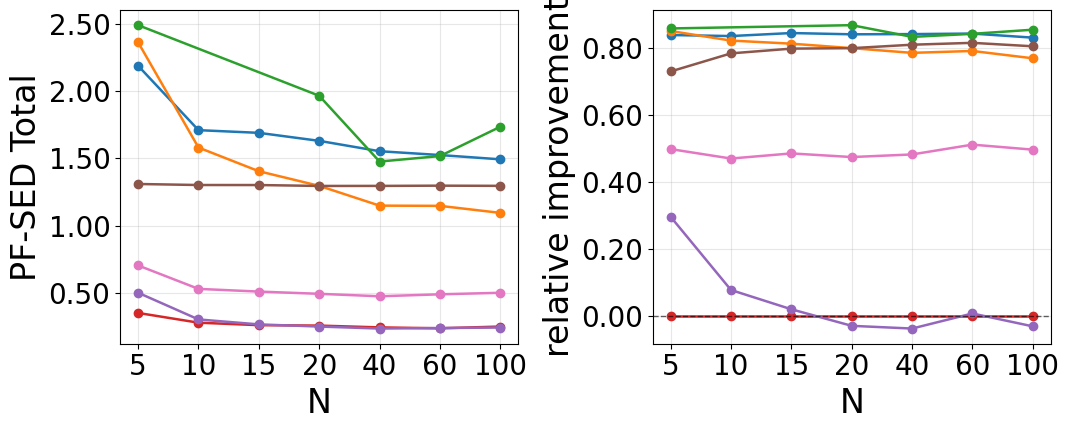

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_RES1.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_RES1.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_RES1_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_RES1_rel_imp.pdf


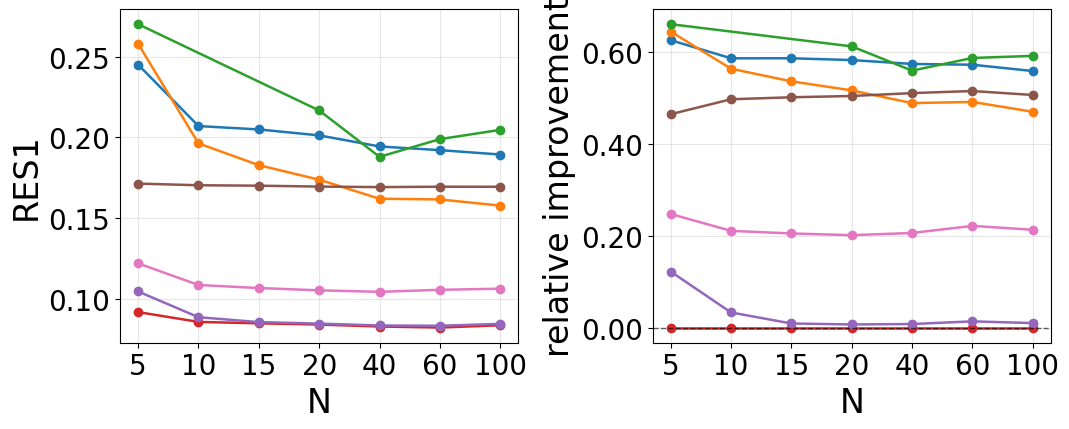

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_Rank-Hist_Var.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_arctan_vs_N_Rank-Hist_Var.pdf


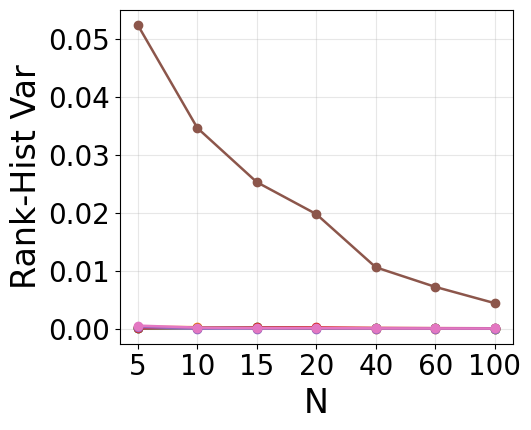

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_State.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_State.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_State_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_State_rel_imp.pdf


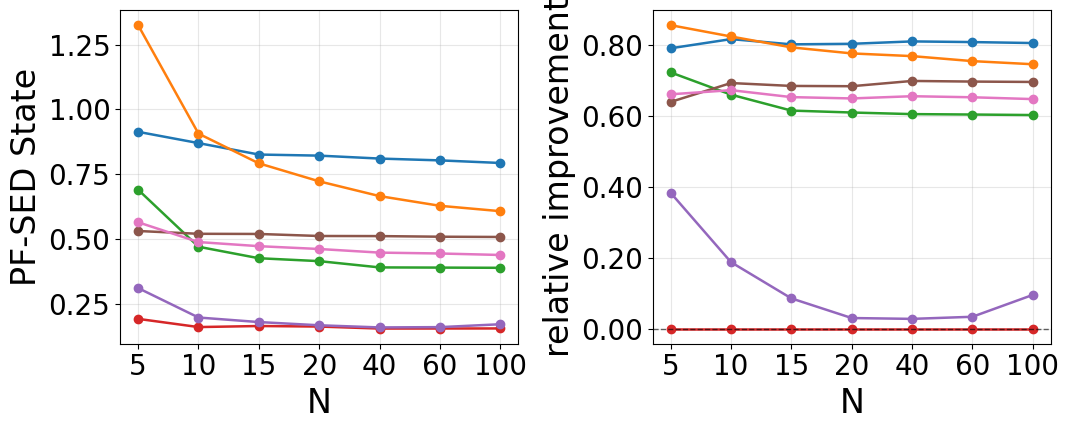

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_PCA.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_PCA.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_PCA_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_PCA_rel_imp.pdf


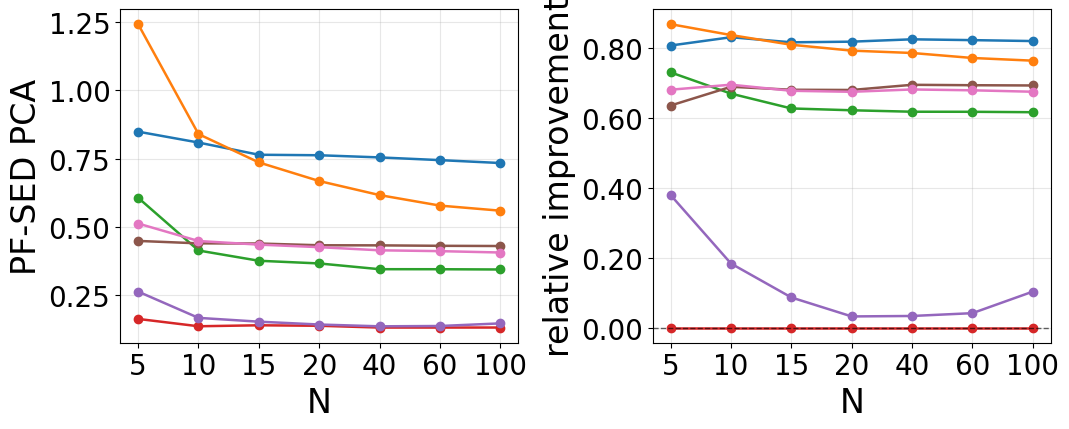

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_Total.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_Total.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_Total_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_PF-SED_Total_rel_imp.pdf


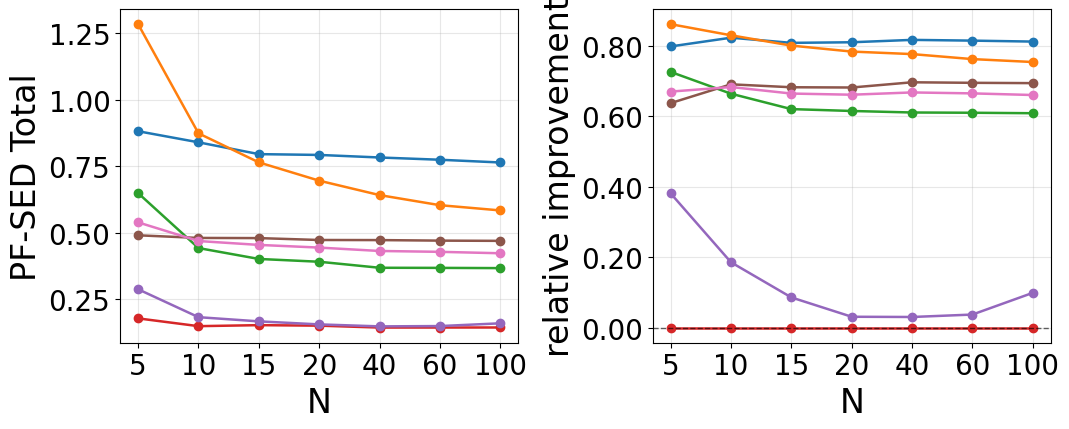

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_RES1.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_RES1.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_RES1_rel_imp.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_RES1_rel_imp.pdf


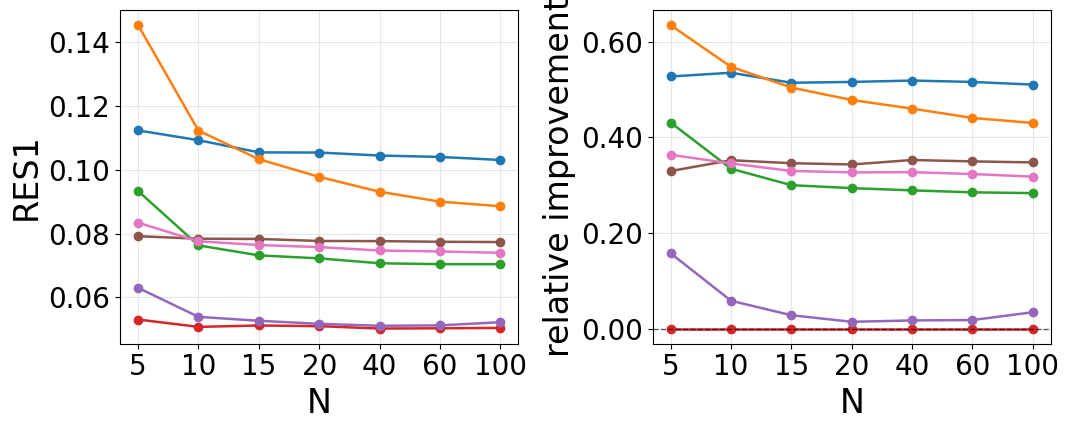

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_vertical_legend.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_Rank-Hist_Var.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_metric_identity_vs_N_Rank-Hist_Var.pdf


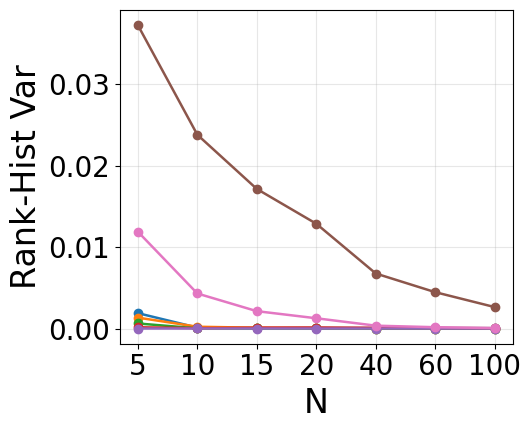

In [8]:
def save_metric_vertical_legend(legend_handles, legend_labels, save_dir=None):
    from matplotlib.lines import Line2D

    save_dir = Path(save_dir or FIG_SAVE_DIR)
    save_dir.mkdir(parents=True, exist_ok=True)
    legend_fig, legend_ax = plt.subplots(
        figsize=(
            METRIC_LEGEND_WIDTH,
            METRIC_LEGEND_HEIGHT_PER_ITEM * len(legend_labels) + METRIC_LEGEND_BASE_HEIGHT,
        )
    )
    legend_ax.axis('off')
    proxy_handles = [
        Line2D([0], [0], color=h.get_color(), marker='o', linewidth=1.8)
        for h in legend_handles
    ]
    legend_ax.legend(
        proxy_handles,
        legend_labels,
        loc='center',
        ncol=1,
        frameon=False,
        fontsize=TICK_FONTSIZE,
        handlelength=2.0,
        handletextpad=0.8,
        labelspacing=0.7,
    )
    legend_fig.tight_layout(pad=0.2)
    out_legend = save_dir / 'L63_metric_vertical_legend.png'
    save_figure_png_pdf(legend_fig, out_legend, dpi=180, bbox_inches='tight', pad_inches=0.02)
    plt.close(legend_fig)


def needs_fixed_two_decimal_yticks(metric_name: str) -> bool:
    metric_name = str(metric_name).upper()
    return ('SED' in metric_name) or ('ES1' in metric_name) or ('RES1' in metric_name)


def apply_metric_yaxis_format(ax, metric_name):
    if needs_fixed_two_decimal_yticks(metric_name):
        from matplotlib.ticker import FormatStrFormatter
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


def use_equal_spaced_metric_x(fig_width):
    return fig_width < METRIC_EQUAL_SPACING_WIDTH_THRESHOLD


def get_metric_plot_x(x_values, fig_width):
    x_values = np.asarray(x_values, dtype=float)
    if use_equal_spaced_metric_x(fig_width):
        return np.arange(len(x_values), dtype=float)
    return x_values


def apply_metric_xaxis_ticks(ax, fig_width):
    if use_equal_spaced_metric_x(fig_width):
        ax.set_xticks(np.arange(len(VAL_N_LIST), dtype=float))
        ax.set_xticklabels([str(v) for v in VAL_N_LIST])
    else:
        ax.set_xticks(VAL_N_LIST)


def _compute_relative_improvement(series, baseline_series):
    series = np.asarray(series, dtype=float)
    baseline_series = np.asarray(baseline_series, dtype=float)
    out = np.full(series.shape, np.nan, dtype=float)
    valid = np.isfinite(series) & np.isfinite(baseline_series) & (np.abs(series) > 1e-12)
    out[valid] = (series[valid] - baseline_series[valid]) / series[valid]
    return out


def plot_metric_vs_N(metric_name, metric_keys, obs_fn=None, save=True, show_relative=True):
    obs_fn = obs_fn or OBS_FN
    method_specs = metric_method_specs[obs_fn]

    metric_curves = {}
    for spec in method_specs:
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        metric_curves[spec['label']] = {'x': x, 'y': y}

    if show_relative:
        baseline_curve = metric_curves.get(BASELINE_METHOD_LABEL)
        if baseline_curve is None:
            print(f'[warn] baseline method missing for obs_fn={obs_fn}: {BASELINE_METHOD_LABEL}')
            baseline_y = np.full(len(VAL_N_LIST), np.nan, dtype=float)
        else:
            baseline_y = baseline_curve['y']
    else:
        baseline_y = None

    if show_relative:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(METRIC_FIG_WIDTH * METRIC_COMBINED_COLS, METRIC_FIG_HEIGHT),
            sharex=False,
        )
        ax_metric, ax_rel = axes
    else:
        fig, ax_metric = plt.subplots(1, 1, figsize=(METRIC_FIG_WIDTH, METRIC_FIG_HEIGHT), sharex=False)
        ax_rel = None
    legend_handles = []
    legend_labels = []

    for spec in method_specs:
        label = spec['label']
        x = metric_curves[label]['x']
        plot_x = get_metric_plot_x(x, METRIC_FIG_WIDTH)
        y = metric_curves[label]['y']
        valid = np.isfinite(y)
        if np.any(valid):
            (line,) = ax_metric.plot(plot_x[valid], y[valid], marker='o', linewidth=1.8, label=label)
        else:
            print(f'[warn] no valid points for metric={metric_name}, obs_fn={obs_fn}, method={label}')
            (line,) = ax_metric.plot([], [], marker='o', linewidth=1.8, label=label)

        if show_relative:
            rel = _compute_relative_improvement(y, baseline_y)
            rel_valid = np.isfinite(rel)
            if np.any(rel_valid):
                ax_rel.plot(plot_x[rel_valid], rel[rel_valid], marker='o', linewidth=1.8, color=line.get_color())
            else:
                print(f'[warn] no valid rel-improvement points for metric={metric_name}, obs_fn={obs_fn}, method={label}')
                ax_rel.plot([], [], marker='o', linewidth=1.8, color=line.get_color())

        legend_handles.append(line)
        legend_labels.append(label)

    ax_metric.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
    ax_metric.set_ylabel(metric_name, fontsize=AXIS_LABEL_FONTSIZE)
    apply_metric_xaxis_ticks(ax_metric, METRIC_FIG_WIDTH)
    ax_metric.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    apply_metric_yaxis_format(ax_metric, metric_name)
    ax_metric.grid(alpha=0.3)

    if show_relative:
        ax_rel.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
        ax_rel.set_ylabel('relative improvement', fontsize=AXIS_LABEL_FONTSIZE)
        apply_metric_xaxis_ticks(ax_rel, METRIC_FIG_WIDTH)
        ax_rel.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        apply_metric_yaxis_format(ax_rel, metric_name)
        ax_rel.grid(alpha=0.3)
        ax_rel.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)

    plt.tight_layout()

    if save:
        safe_name = re.sub(r'[^0-9a-zA-Z._-]+', '_', metric_name)

        save_metric_vertical_legend(legend_handles, legend_labels)

        metric_fig, metric_ax = plt.subplots(figsize=(METRIC_FIG_WIDTH, METRIC_FIG_HEIGHT))
        for handle, label in zip(legend_handles, legend_labels):
            curve = metric_curves[label]
            plot_x = get_metric_plot_x(curve['x'], METRIC_FIG_WIDTH)
            valid = np.isfinite(curve['y'])
            metric_ax.plot(plot_x[valid], curve['y'][valid], marker='o', linewidth=1.8, color=handle.get_color())
        metric_ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
        metric_ax.set_ylabel(metric_name, fontsize=AXIS_LABEL_FONTSIZE)
        apply_metric_xaxis_ticks(metric_ax, METRIC_FIG_WIDTH)
        metric_ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        apply_metric_yaxis_format(metric_ax, metric_name)
        metric_ax.grid(alpha=0.3)
        metric_fig.tight_layout()
        out_metric = FIG_SAVE_DIR / f'L63_metric_{obs_fn}_vs_N_{safe_name}.png'
        save_figure_png_pdf(metric_fig, out_metric, dpi=180, bbox_inches='tight')
        plt.close(metric_fig)

        if show_relative:
            rel_fig, rel_ax = plt.subplots(figsize=(METRIC_FIG_WIDTH, METRIC_FIG_HEIGHT))
            for handle, label in zip(legend_handles, legend_labels):
                curve = metric_curves[label]
                plot_x = get_metric_plot_x(curve['x'], METRIC_FIG_WIDTH)
                rel = _compute_relative_improvement(curve['y'], baseline_y)
                rel_valid = np.isfinite(rel)
                rel_ax.plot(plot_x[rel_valid], rel[rel_valid], marker='o', linewidth=1.8, color=handle.get_color())
            rel_ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
            rel_ax.set_ylabel('relative improvement', fontsize=AXIS_LABEL_FONTSIZE)
            apply_metric_xaxis_ticks(rel_ax, METRIC_FIG_WIDTH)
            rel_ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            apply_metric_yaxis_format(rel_ax, metric_name)
            rel_ax.grid(alpha=0.3)
            rel_ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
            rel_fig.tight_layout()
            out_rel = FIG_SAVE_DIR / f'L63_metric_{obs_fn}_vs_N_{safe_name}_rel_imp.png'
            save_figure_png_pdf(rel_fig, out_rel, dpi=180, bbox_inches='tight')
            plt.close(rel_fig)

    plt.show()


for obs_fn in METRIC_OBS_FN_LIST:
    for metric_name, metric_keys, show_relative in METRIC_SPECS:
        plot_metric_vs_N(metric_name, metric_keys, obs_fn=obs_fn, show_relative=show_relative)


## Combined multi-observation figures

Render SED, SED relative improvement, RHVar, and standalone legends as PDF files.


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_combined_metrics_3x3.pdf


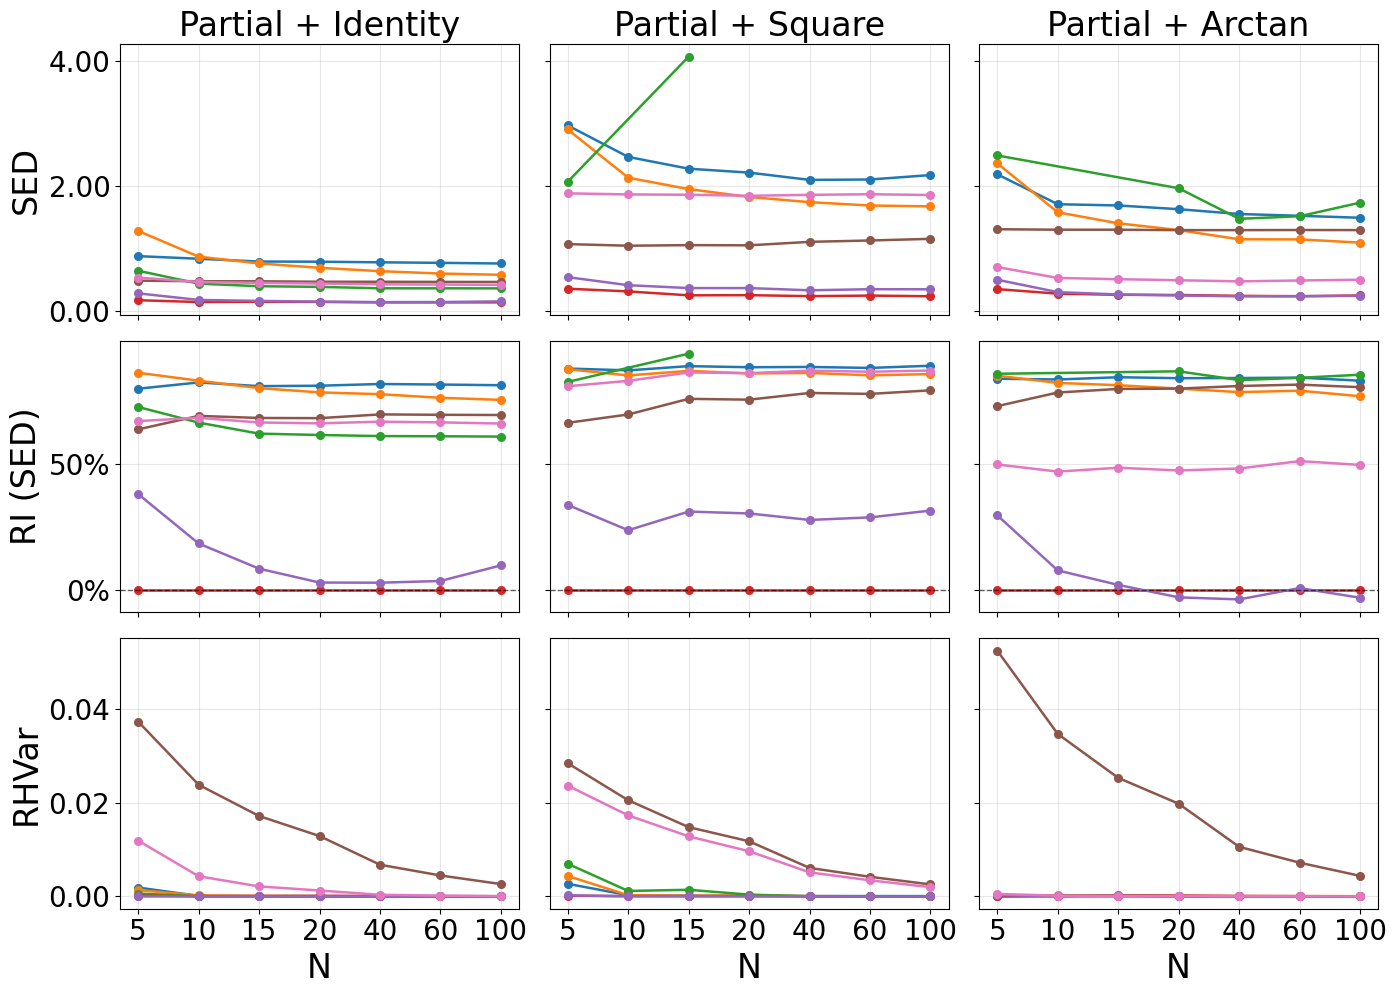

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_combined_metric_legend_vertical.pdf


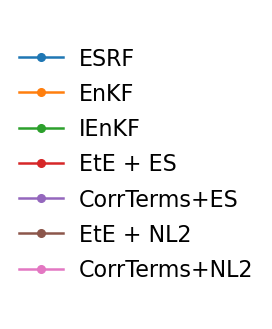

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/L63_combined_metric_legend_horizontal.pdf


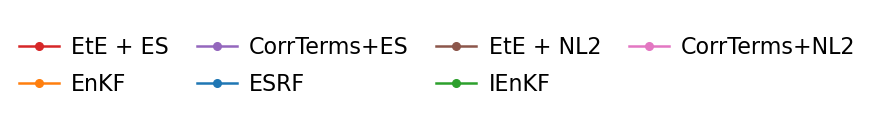

In [9]:

# =========================
# Combined multi-observation figures
# =========================
COMBINED_OBS_FN_LIST = ['identity', 'square', 'arctan']
COMBINED_OBS_FN_TITLES = {
    'identity': 'Partial + Identity',
    'square': 'Partial + Square',
    'arctan': 'Partial + Arctan',
}
COMBINED_PANEL_WIDTH = 4.7
COMBINED_PANEL_HEIGHT = 4.2
COMBINED_LINEWIDTH = 1.8
COMBINED_MARKERSIZE = 5.5
COMBINED_LEGEND_FONTSIZE = 16
COMBINED_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'IEnKF': 2,
    'EtE + ES': 3,
    'CorrTerms+ES': 4,
    'EtE + NL2': 5,
    'CorrTerms+NL2': 6,
}


def _is_combined_metric_method(spec):
    method = spec.get('method', '')
    return (not str(method).startswith('iEnKS-')) or method == 'iEnKS-PertObs'


def _combined_method_specs(obs_fn):
    specs = []
    for spec in metric_method_specs[obs_fn]:
        if not _is_combined_metric_method(spec):
            continue
        spec = dict(spec)
        if spec.get('method') == 'iEnKS-PertObs':
            spec['label'] = 'IEnKF'
        specs.append(spec)
    return specs


def _combined_method_labels():
    labels = []
    for obs_fn in COMBINED_OBS_FN_LIST:
        for spec in _combined_method_specs(obs_fn):
            label = spec['label']
            if label not in labels:
                labels.append(label)
    return sorted(labels, key=lambda label: (COMBINED_METHOD_ORDER.get(label, 999), label))


COMBINED_METHOD_LABELS = _combined_method_labels()
COMBINED_COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
COMBINED_METHOD_COLORS = {
    label: COMBINED_COLOR_CYCLE[i % len(COMBINED_COLOR_CYCLE)]
    for i, label in enumerate(COMBINED_METHOD_LABELS)
}


def _combined_plot_x(x_values, fig_width):
    if 'get_metric_plot_x' in globals():
        return get_metric_plot_x(x_values, fig_width)
    x_values = np.asarray(x_values, dtype=float)
    if fig_width < METRIC_EQUAL_SPACING_WIDTH_THRESHOLD:
        return np.arange(len(x_values), dtype=float)
    return x_values


def _combined_apply_xaxis_ticks(ax, fig_width):
    if 'apply_metric_xaxis_ticks' in globals():
        apply_metric_xaxis_ticks(ax, fig_width)
        return
    if fig_width < METRIC_EQUAL_SPACING_WIDTH_THRESHOLD:
        ax.set_xticks(np.arange(len(VAL_N_LIST), dtype=float))
        ax.set_xticklabels([str(v) for v in VAL_N_LIST])
    else:
        ax.set_xticks(VAL_N_LIST)


def _combined_relative_improvement(series, baseline_series):
    if '_compute_relative_improvement' in globals():
        return _compute_relative_improvement(series, baseline_series)
    series = np.asarray(series, dtype=float)
    baseline_series = np.asarray(baseline_series, dtype=float)
    out = np.full(series.shape, np.nan, dtype=float)
    valid = np.isfinite(series) & np.isfinite(baseline_series) & (np.abs(series) > 1e-12)
    out[valid] = (series[valid] - baseline_series[valid]) / series[valid]
    return out


def _combined_apply_yaxis_format(ax, metric_name):
    if 'apply_metric_yaxis_format' in globals():
        apply_metric_yaxis_format(ax, metric_name)
        return
    if 'SED' in str(metric_name).upper():
        from matplotlib.ticker import FormatStrFormatter
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


def _save_pdf_only(fig, out_path, **savefig_kwargs):
    out_path = Path(out_path).with_suffix('.pdf')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, **savefig_kwargs)
    print('Saved:', out_path)
    return out_path


def save_combined_metric_legends(labels=None):
    from matplotlib.lines import Line2D

    labels = list(labels or COMBINED_METHOD_LABELS)

    def make_handle(label):
        return Line2D(
            [0],
            [0],
            color=COMBINED_METHOD_COLORS[label],
            marker='o',
            linewidth=COMBINED_LINEWIDTH,
            markersize=COMBINED_MARKERSIZE,
        )

    handles = [make_handle(label) for label in labels]

    vertical_fig, vertical_ax = plt.subplots(
        figsize=(2.4, 0.42 * len(labels) + 0.25)
    )
    vertical_ax.axis('off')
    vertical_ax.legend(
        handles,
        labels,
        loc='center',
        ncol=1,
        frameon=False,
        fontsize=COMBINED_LEGEND_FONTSIZE,
        handlelength=2.0,
        handletextpad=0.7,
        labelspacing=0.55,
    )
    vertical_fig.tight_layout(pad=0.1)
    _save_pdf_only(
        vertical_fig,
        FIG_SAVE_DIR / 'L63_combined_metric_legend_vertical.pdf',
        bbox_inches='tight',
        pad_inches=0.02,
    )
    plt.show()
    plt.close(vertical_fig)

    horizontal_row_1 = ['EtE + ES', 'CorrTerms+ES', 'EtE + NL2', 'CorrTerms+NL2']
    horizontal_row_2 = ['EnKF', 'ESRF', 'IEnKF']
    horizontal_row_1 = [label for label in horizontal_row_1 if label in labels]
    horizontal_row_2 = [label for label in horizontal_row_2 if label in labels]
    horizontal_ncol = max(len(horizontal_row_1), len(horizontal_row_2))
    horizontal_labels = []
    for col_idx in range(horizontal_ncol):
        if col_idx < len(horizontal_row_1):
            horizontal_labels.append(horizontal_row_1[col_idx])
        if col_idx < len(horizontal_row_2):
            horizontal_labels.append(horizontal_row_2[col_idx])
    horizontal_handles = [make_handle(label) for label in horizontal_labels]

    horizontal_fig, horizontal_ax = plt.subplots(
        figsize=(max(7.4, 1.65 * horizontal_ncol), 1.15)
    )
    horizontal_ax.axis('off')
    horizontal_ax.legend(
        horizontal_handles,
        horizontal_labels,
        loc='center',
        ncol=horizontal_ncol,
        frameon=False,
        fontsize=COMBINED_LEGEND_FONTSIZE,
        handlelength=1.8,
        handletextpad=0.55,
        columnspacing=1.25,
        labelspacing=0.65,
    )
    horizontal_fig.tight_layout(pad=0.1)
    _save_pdf_only(
        horizontal_fig,
        FIG_SAVE_DIR / 'L63_combined_metric_legend_horizontal.pdf',
        bbox_inches='tight',
        pad_inches=0.02,
    )
    plt.show()
    plt.close(horizontal_fig)


def _combined_metric_curves(obs_fn, metric_keys):
    curves = {}
    for spec in _combined_method_specs(obs_fn):
        label = spec['label']
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        curves[label] = {'x': x, 'y': y}
    return curves


def plot_combined_metric_triptych(metric_keys, ylabel, out_stem, relative=False, yscale='linear'):
    from matplotlib.ticker import PercentFormatter

    fig, axes = plt.subplots(
        1,
        len(COMBINED_OBS_FN_LIST),
        figsize=(COMBINED_PANEL_WIDTH * len(COMBINED_OBS_FN_LIST), COMBINED_PANEL_HEIGHT),
        sharey=True,
    )

    for ax, obs_fn in zip(axes, COMBINED_OBS_FN_LIST):
        curves = _combined_metric_curves(obs_fn, metric_keys)
        baseline_y = curves.get(BASELINE_METHOD_LABEL, {}).get(
            'y', np.full(len(VAL_N_LIST), np.nan, dtype=float)
        )

        for label in COMBINED_METHOD_LABELS:
            if label not in curves:
                continue
            curve = curves[label]
            x = curve['x']
            y = curve['y']
            plot_y = 100.0 * _combined_relative_improvement(y, baseline_y) if relative else y
            valid = np.isfinite(plot_y)
            plot_x = _combined_plot_x(x, COMBINED_PANEL_WIDTH)
            ax.plot(
                plot_x[valid],
                plot_y[valid],
                marker='o',
                linewidth=COMBINED_LINEWIDTH,
                markersize=COMBINED_MARKERSIZE,
                color=COMBINED_METHOD_COLORS[label],
            )

        ax.set_title(COMBINED_OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
        _combined_apply_xaxis_ticks(ax, COMBINED_PANEL_WIDTH)
        ax.set_yscale(yscale)
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        ax.grid(alpha=0.3, which='both' if yscale == 'log' else 'major')
        if relative:
            ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=100.0, decimals=0))
        elif ylabel == 'SED':
            _combined_apply_yaxis_format(ax, 'SED')

    axes[0].set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    fig.tight_layout(w_pad=1.5)
    _save_pdf_only(fig, FIG_SAVE_DIR / f'{out_stem}.pdf', bbox_inches='tight')
    plt.show()


def plot_combined_metric_grid_3x3(out_stem='L63_combined_metrics_3x3'):
    from matplotlib.ticker import PercentFormatter

    row_specs = [
        {'ylabel': 'SED', 'keys': ['mean_pf_sed', 'mean_pf_crps'], 'relative': False},
        {'ylabel': 'RI (SED)', 'keys': ['mean_pf_sed', 'mean_pf_crps'], 'relative': True},
        {'ylabel': 'RHVar', 'keys': ['rank_freq_var'], 'relative': False},
    ]
    fig, axes = plt.subplots(
        len(row_specs),
        len(COMBINED_OBS_FN_LIST),
        figsize=(COMBINED_PANEL_WIDTH * len(COMBINED_OBS_FN_LIST), 3.35 * len(row_specs)),
        sharex='col',
        sharey='row',
    )

    for col_idx, obs_fn in enumerate(COMBINED_OBS_FN_LIST):
        axes[0, col_idx].set_title(COMBINED_OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
        for row_idx, row in enumerate(row_specs):
            ax = axes[row_idx, col_idx]
            curves = _combined_metric_curves(obs_fn, row['keys'])
            baseline_y = curves.get(BASELINE_METHOD_LABEL, {}).get(
                'y', np.full(len(VAL_N_LIST), np.nan, dtype=float)
            )

            for label in COMBINED_METHOD_LABELS:
                if label not in curves:
                    continue
                curve = curves[label]
                y = curve['y']
                plot_y = 100.0 * _combined_relative_improvement(y, baseline_y) if row['relative'] else y
                valid = np.isfinite(plot_y)
                plot_x = _combined_plot_x(curve['x'], COMBINED_PANEL_WIDTH)
                ax.plot(
                    plot_x[valid],
                    plot_y[valid],
                    marker='o',
                    linewidth=COMBINED_LINEWIDTH,
                    markersize=COMBINED_MARKERSIZE,
                    color=COMBINED_METHOD_COLORS[label],
                )

            _combined_apply_xaxis_ticks(ax, COMBINED_PANEL_WIDTH)
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
            ax.grid(alpha=0.3)
            if row['relative']:
                ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
                ax.yaxis.set_major_formatter(PercentFormatter(xmax=100.0, decimals=0))
            elif row['ylabel'] == 'SED':
                _combined_apply_yaxis_format(ax, 'SED')

            if col_idx == 0:
                ax.set_ylabel(row['ylabel'], fontsize=AXIS_LABEL_FONTSIZE)
            if row_idx == len(row_specs) - 1:
                ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)

    fig.tight_layout(w_pad=1.0, h_pad=0.9)
    _save_pdf_only(fig, FIG_SAVE_DIR / f'{out_stem}.pdf', bbox_inches='tight')
    plt.show()


plot_combined_metric_grid_3x3()
save_combined_metric_legends()


## Assimilation-time comparison

The `output_records_*.pt` files include per-assimilation-step timing fields. The plot below renders the timing comparison separately from the 3x3 metric grid.


Assimilation-time fields used, in priority order:
  mean: ['assim_step_time_mean_weighted', 'mean_assim_time_w', 'assim_step_time_mean', 'mean_assim_time']
  std : ['assim_step_time_std_weighted', 'std_assim_time_w', 'assim_step_time_std', 'std_assim_time']
obs_fn=identity
  ESRF: 7/7 valid N values
  EnKF: 7/7 valid N values
  IEnKF: 7/7 valid N values
  EtE + ES: 7/7 valid N values
  CorrTerms+ES: 7/7 valid N values
  EtE + NL2: 7/7 valid N values
  CorrTerms+NL2: 7/7 valid N values
obs_fn=square
  ESRF: 7/7 valid N values
  EnKF: 7/7 valid N values
  IEnKF: 7/7 valid N values
  EtE + ES: 7/7 valid N values
  CorrTerms+ES: 7/7 valid N values
  EtE + NL2: 7/7 valid N values
  CorrTerms+NL2: 7/7 valid N values
obs_fn=arctan
  ESRF: 7/7 valid N values
  EnKF: 7/7 valid N values
  IEnKF: 7/7 valid N values
  EtE + ES: 7/7 valid N values
  CorrTerms+ES: 7/7 valid N values
  EtE + NL2: 7/7 valid N values
  CorrTerms+NL2: 7/7 valid N values
Saved: /home/bhchen/LearnKalmanGain/save/figures/l

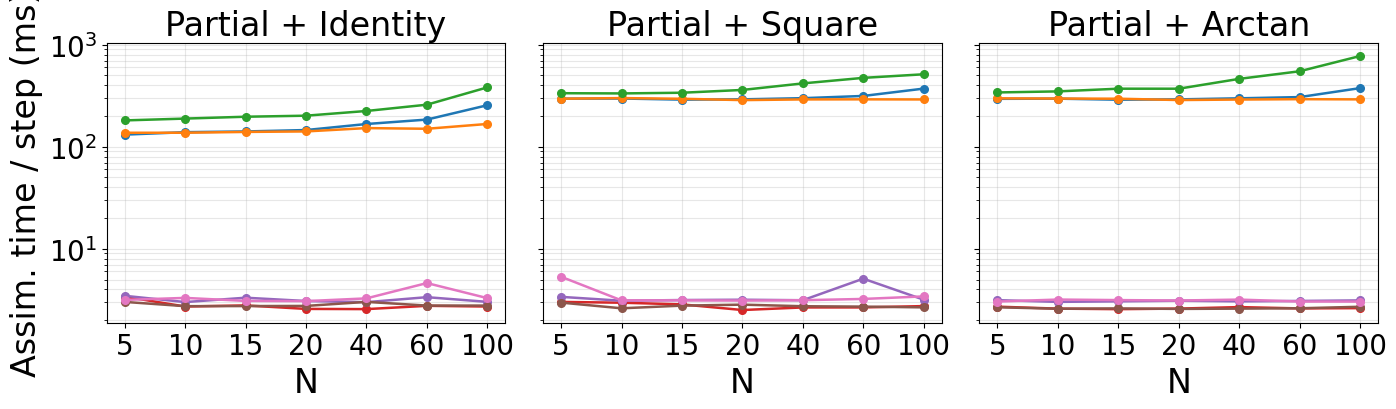

In [10]:

# =========================
# Assimilation-time comparison (kept separate from the 3x3 metric grid)
# =========================
ASSIM_TIME_KEYS = [
    'assim_step_time_mean_weighted',
    'mean_assim_time_w',
    'assim_step_time_mean',
    'mean_assim_time',
]
ASSIM_TIME_STD_KEYS = [
    'assim_step_time_std_weighted',
    'std_assim_time_w',
    'assim_step_time_std',
    'std_assim_time',
]
ASSIM_TIME_UNIT_SCALE = 1000.0  # records store seconds; plot milliseconds
ASSIM_TIME_YLABEL = 'Assim. time / step (ms)'
ASSIM_TIME_YSCALE = 'log'


def collect_assim_time_table(method_spec, n_values):
    xs, means, stds = [], [], []
    for N in n_values:
        rec_path = method_spec['dir'] / f'output_records_{N}.pt'
        if rec_path.exists():
            record = safe_torch_load(rec_path)
            mean_val = metric_from_record(record, ASSIM_TIME_KEYS)
            std_val = metric_from_record(record, ASSIM_TIME_STD_KEYS)
        else:
            mean_val = np.nan
            std_val = np.nan
        xs.append(N)
        means.append(ASSIM_TIME_UNIT_SCALE * mean_val if np.isfinite(mean_val) else np.nan)
        stds.append(ASSIM_TIME_UNIT_SCALE * std_val if np.isfinite(std_val) else np.nan)
    return np.array(xs, dtype=float), np.array(means, dtype=float), np.array(stds, dtype=float)


def _combined_assim_time_curves(obs_fn):
    curves = {}
    for spec in _combined_method_specs(obs_fn):
        label = spec['label']
        x, mean, std = collect_assim_time_table(spec, VAL_N_LIST)
        curves[label] = {'x': x, 'mean': mean, 'std': std}
    return curves


def print_assim_time_availability():
    print('Assimilation-time fields used, in priority order:')
    print('  mean:', ASSIM_TIME_KEYS)
    print('  std :', ASSIM_TIME_STD_KEYS)
    for obs_fn in COMBINED_OBS_FN_LIST:
        curves = _combined_assim_time_curves(obs_fn)
        print('==================================================')
        print(f'obs_fn={obs_fn}')
        for label in COMBINED_METHOD_LABELS:
            if label not in curves:
                continue
            valid_count = int(np.isfinite(curves[label]['mean']).sum())
            print(f'  {label}: {valid_count}/{len(VAL_N_LIST)} valid N values')


def plot_combined_assim_time_triptych(out_stem='L63_combined_assim_time_vs_N'):
    fig, axes = plt.subplots(
        1,
        len(COMBINED_OBS_FN_LIST),
        figsize=(COMBINED_PANEL_WIDTH * len(COMBINED_OBS_FN_LIST), COMBINED_PANEL_HEIGHT),
        sharey=True,
    )

    for ax, obs_fn in zip(axes, COMBINED_OBS_FN_LIST):
        curves = _combined_assim_time_curves(obs_fn)
        for label in COMBINED_METHOD_LABELS:
            if label not in curves:
                continue
            curve = curves[label]
            y = curve['mean']
            valid = np.isfinite(y) & (y > 0)
            if not np.any(valid):
                print(f'[warn] no valid assimilation-time points for obs_fn={obs_fn}, method={label}')
                continue
            plot_x = _combined_plot_x(curve['x'], COMBINED_PANEL_WIDTH)
            ax.plot(
                plot_x[valid],
                y[valid],
                marker='o',
                linewidth=COMBINED_LINEWIDTH,
                markersize=COMBINED_MARKERSIZE,
                color=COMBINED_METHOD_COLORS[label],
            )

        ax.set_title(COMBINED_OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
        _combined_apply_xaxis_ticks(ax, COMBINED_PANEL_WIDTH)
        ax.set_yscale(ASSIM_TIME_YSCALE)
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        ax.grid(alpha=0.3, which='both')

    axes[0].set_ylabel(ASSIM_TIME_YLABEL, fontsize=AXIS_LABEL_FONTSIZE)
    fig.tight_layout(w_pad=1.5)
    _save_pdf_only(fig, FIG_SAVE_DIR / f'{out_stem}.pdf', bbox_inches='tight')
    plt.show()


print_assim_time_availability()
plot_combined_assim_time_triptych()
